# Phase 2: Monaco 2025 Data Cleaning and Exploratory Analysis

## Objective

The goal of this notebook is to clean the raw 2025 Monaco Grand Prix lap data collected from FastF1.

In this phase, we will convert lap times into seconds, identify pit laps, remove invalid or unusable laps, inspect tyre compounds and stints, and create basic exploratory charts to understand race pace, tyre usage, and lap-time patterns.

This cleaned dataset will be used in the next phases for tyre degradation analysis and machine learning model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

 Set path

In [2]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
OUTPUTS_DIR = Path("../outputs/figures")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

laps_path = RAW_DATA_DIR / "2025_monaco_race_laps.csv"
weather_path = RAW_DATA_DIR / "2025_monaco_weather.csv"
results_path = RAW_DATA_DIR / "2025_monaco_results.csv"

Load Raw Data

In [3]:
laps = pd.read_csv(laps_path)
weather = pd.read_csv(weather_path)
results = pd.read_csv(results_path)

print("Laps shape:", laps.shape)
print("Weather shape:", weather.shape)
print("Results shape:", results.shape)

Laps shape: (1425, 31)
Weather shape: (160, 8)
Results shape: (20, 22)


In [4]:
laps.columns.tolist()

['Time',
 'Driver',
 'DriverNumber',
 'LapTime',
 'LapNumber',
 'Stint',
 'PitOutTime',
 'PitInTime',
 'Sector1Time',
 'Sector2Time',
 'Sector3Time',
 'Sector1SessionTime',
 'Sector2SessionTime',
 'Sector3SessionTime',
 'SpeedI1',
 'SpeedI2',
 'SpeedFL',
 'SpeedST',
 'IsPersonalBest',
 'Compound',
 'TyreLife',
 'FreshTyre',
 'Team',
 'LapStartTime',
 'LapStartDate',
 'TrackStatus',
 'Position',
 'Deleted',
 'DeletedReason',
 'FastF1Generated',
 'IsAccurate']

## Convert Lap Time to Seconds

FastF1 stores lap time as a time duration. For machine learning, we need a numeric target variable. We will convert `LapTime` into total seconds and store it as `LapTimeSeconds`.

In [5]:
# Convert LapTime to timedeltas, then seconds

laps["LapTime"] = pd.to_timedelta(laps["LapTime"], errors="coerce")
laps["LapTimeSeconds"] = laps["LapTime"].dt.total_seconds()

laps[["Driver", "LapNumber", "LapTime", "LapTimeSeconds"]].head()

,Driver,LapNumber,LapTime,LapTimeSeconds
0,VER,1.0,0 days 00:01:27.020000,87.020
1,VER,2.0,0 days 00:01:46.318000,106.318
2,VER,3.0,0 days 00:01:48.815000,108.815
3,VER,4.0,0 days 00:01:40.290000,100.290
4,VER,5.0,0 days 00:01:20.800000,80.800


In [6]:
missing_lap_times = laps["LapTimeSeconds"].isna().sum()
total_rows = len(laps)

print(f"Missing lap times: {missing_lap_times}")
print(f"Total rows: {total_rows}")
print(f"Missing percentage: {missing_lap_times / total_rows:.2%}")

Missing lap times: 2
Total rows: 1425
Missing percentage: 0.14%


## Identify Pit Laps

Pit in-laps and out-laps usually have abnormal lap times because the car enters or exits the pit lane. We will keep a flag for pit laps, but remove them from some analysis where we want to compare normal racing pace.

create pit lap flag

In [7]:
laps["IsPitLap"] = laps["PitInTime"].notna() | laps["PitOutTime"].notna()

laps[["Driver", "LapNumber", "PitInTime", "PitOutTime", "IsPitLap"]].head(10)

,Driver,LapNumber,PitInTime,PitOutTime,IsPitLap
0,VER,1.0,NaN,NaN,False
1,VER,2.0,NaN,NaN,False
2,VER,3.0,NaN,NaN,False
3,VER,4.0,NaN,NaN,False
4,VER,5.0,NaN,NaN,False
5,VER,6.0,NaN,NaN,False
6,VER,7.0,NaN,NaN,False
7,VER,8.0,NaN,NaN,False
8,VER,9.0,NaN,NaN,False
9,VER,10.0,NaN,NaN,False


pit lap by driver

In [8]:
pit_laps_by_driver = (
    laps.groupby("Driver")["IsPitLap"]
    .sum()
    .sort_values(ascending=False)
)

pit_laps_by_driver

Driver
BOR    6
RUS    6
ALB    4
LEC    4
TSU    4
STR    4
SAI    4
PIA    4
OCO    4
NOR    4
LAW    4
HUL    4
HAM    4
HAD    4
COL    4
BEA    4
ANT    4
VER    4
GAS    3
ALO    2
Name: IsPitLap, dtype: int64

## Clean the Lap Dataset

For the clean dataset, we will remove rows where lap time is missing. We will also create a separate `clean_racing_laps` dataset that excludes pit laps and extreme outliers for pace analysis.

We will not delete pit laps permanently because they are useful for strategy analysis.

In [9]:
clean_laps = laps.copy()

# Remove rows with missing lap time
clean_laps = clean_laps.dropna(subset=["LapTimeSeconds"])

# Make sure key numeric columns are numeric
numeric_cols = ["LapNumber", "TyreLife", "Stint", "Position"]

for col in numeric_cols:
    if col in clean_laps.columns:
        clean_laps[col] = pd.to_numeric(clean_laps[col], errors="coerce")

print("Original laps shape:", laps.shape)
print("Clean laps shape:", clean_laps.shape)

Original laps shape: (1425, 33)
Clean laps shape: (1423, 33)


## Check tyre compounds

In [10]:
compound_counts = clean_laps["Compound"].value_counts(dropna=False)
compound_counts

Compound
HARD      848
MEDIUM    518
SOFT       57
Name: count, dtype: int64

## Check tyre life

In [11]:
clean_laps[["Driver", "LapNumber", "Compound", "TyreLife", "Stint"]].head(20)

,Driver,LapNumber,Compound,TyreLife,Stint
0,VER,1.0,HARD,1.0,1.0
1,VER,2.0,HARD,2.0,1.0
2,VER,3.0,HARD,3.0,1.0
3,VER,4.0,HARD,4.0,1.0
4,VER,5.0,HARD,5.0,1.0
5,VER,6.0,HARD,6.0,1.0
6,VER,7.0,HARD,7.0,1.0
7,VER,8.0,HARD,8.0,1.0
8,VER,9.0,HARD,9.0,1.0
9,VER,10.0,HARD,10.0,1.0


## Remove Extreme Lap-Time Outliers for EDA

Some laps may be much slower because of pit stops, safety car periods, yellow flags, traffic, or incidents. For basic race pace charts, we will create a filtered dataset that removes pit laps and extreme lap-time outliers.

This filtered dataset is for exploratory analysis only. The main cleaned dataset will still keep all valid laps with flags.

In [12]:
# Remove pit laps first
racing_laps = clean_laps[clean_laps["IsPitLap"] == False].copy()

# Remove extreme outliers using a reasonable percentile filter
lower_bound = racing_laps["LapTimeSeconds"].quantile(0.01)
upper_bound = racing_laps["LapTimeSeconds"].quantile(0.99)

racing_laps_filtered = racing_laps[
    (racing_laps["LapTimeSeconds"] >= lower_bound) &
    (racing_laps["LapTimeSeconds"] <= upper_bound)
].copy()

print("Clean laps:", clean_laps.shape)
print("Racing laps:", racing_laps.shape)
print("Filtered racing laps:", racing_laps_filtered.shape)

print("Lap time lower bound:", lower_bound)
print("Lap time upper bound:", upper_bound)

Clean laps: (1423, 33)
Racing laps: (1343, 33)
Filtered racing laps: (1315, 33)
Lap time lower bound: 73.9474
Lap time upper bound: 109.29377999999998


## Race Pace by Driver

This chart shows each driver's lap-time trend across the race. Monaco is a track where track position and traffic matter a lot, so we should expect some drivers to run at controlled pace rather than maximum pace every lap.

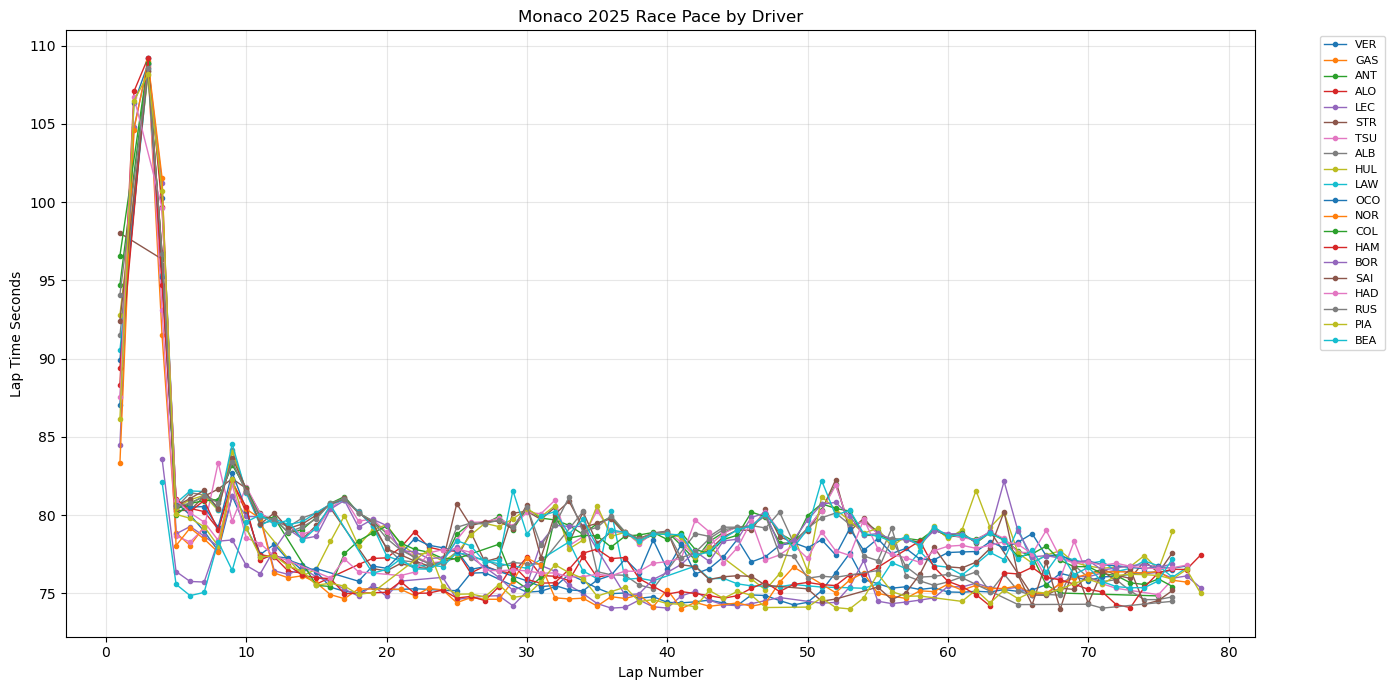

In [13]:
selected_drivers = racing_laps_filtered["Driver"].unique()

plt.figure(figsize=(14, 7))

for driver in selected_drivers:
    driver_data = racing_laps_filtered[racing_laps_filtered["Driver"] == driver]
    plt.plot(
        driver_data["LapNumber"],
        driver_data["LapTimeSeconds"],
        marker="o",
        linewidth=1,
        markersize=3,
        label=driver
    )

plt.title("Monaco 2025 Race Pace by Driver")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time Seconds")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUTS_DIR / "monaco_2025_race_pace_by_driver.png", dpi=300)
plt.show()

## Average Race Pace by Driver

This chart compares each driver's average clean racing lap time. Lower values indicate faster average race pace.

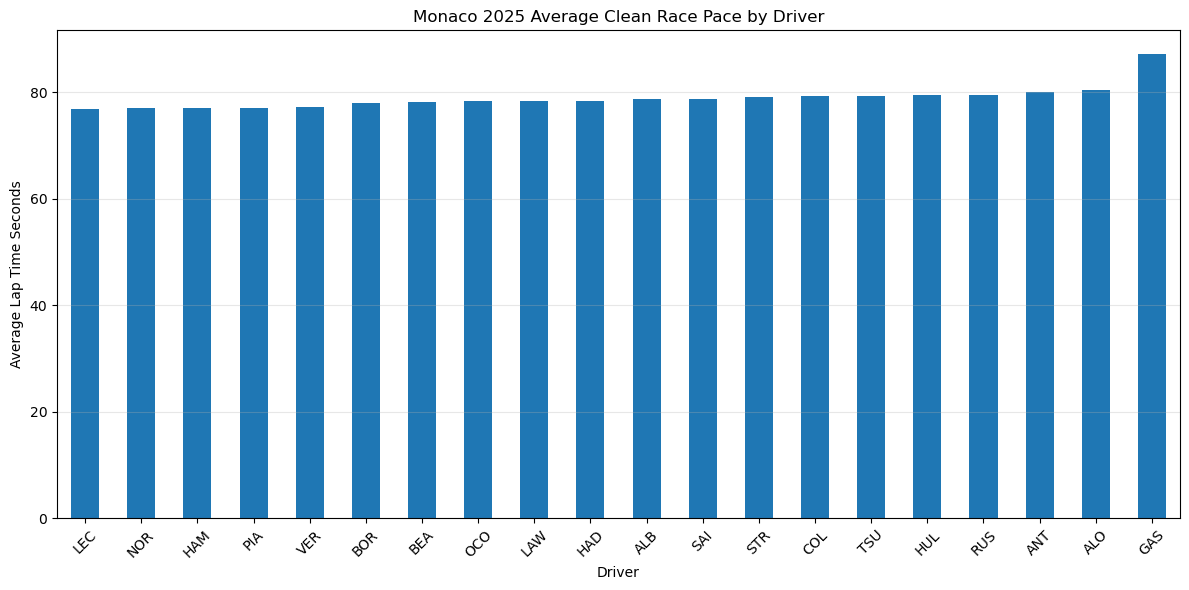

Driver
LEC    76.964676
NOR    77.046292
HAM    77.107603
PIA    77.109845
VER    77.190419
BOR    78.077638
BEA    78.187662
OCO    78.348764
LAW    78.363875
HAD    78.377347
ALB    78.658817
SAI    78.781437
STR    79.036714
COL    79.271479
TSU    79.374264
HUL    79.482620
RUS    79.523226
ANT    79.993088
ALO    80.372088
GAS    87.282400
Name: LapTimeSeconds, dtype: float64

In [14]:
avg_pace_by_driver = (
    racing_laps_filtered
    .groupby("Driver")["LapTimeSeconds"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12, 6))
avg_pace_by_driver.plot(kind="bar")

plt.title("Monaco 2025 Average Clean Race Pace by Driver")
plt.xlabel("Driver")
plt.ylabel("Average Lap Time Seconds")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUTS_DIR / "monaco_2025_average_pace_by_driver.png", dpi=300)
plt.show()

avg_pace_by_driver

## Lap Time by Tyre Compound

This chart compares lap-time distributions for each tyre compound used during the race.

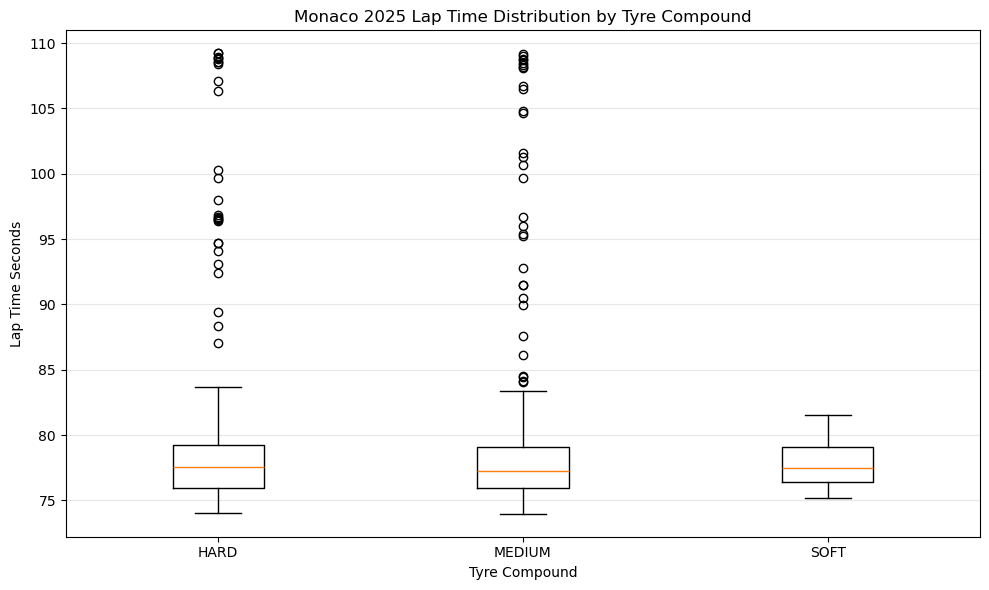

In [16]:
compound_order = racing_laps_filtered["Compound"].dropna().unique()

plt.figure(figsize=(10, 6))

data_to_plot = [
    racing_laps_filtered[racing_laps_filtered["Compound"] == compound]["LapTimeSeconds"]
    for compound in compound_order
]

plt.boxplot(data_to_plot, tick_labels=compound_order)

plt.title("Monaco 2025 Lap Time Distribution by Tyre Compound")
plt.xlabel("Tyre Compound")
plt.ylabel("Lap Time Seconds")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUTS_DIR / "monaco_2025_lap_time_by_compound.png", dpi=300)
plt.show()

## Tyre Life vs Lap Time

This chart is our first look at tyre degradation. If lap times increase as tyre life increases, that may indicate tyre degradation. At Monaco, this relationship may be less obvious because traffic and pace management can also influence lap times.

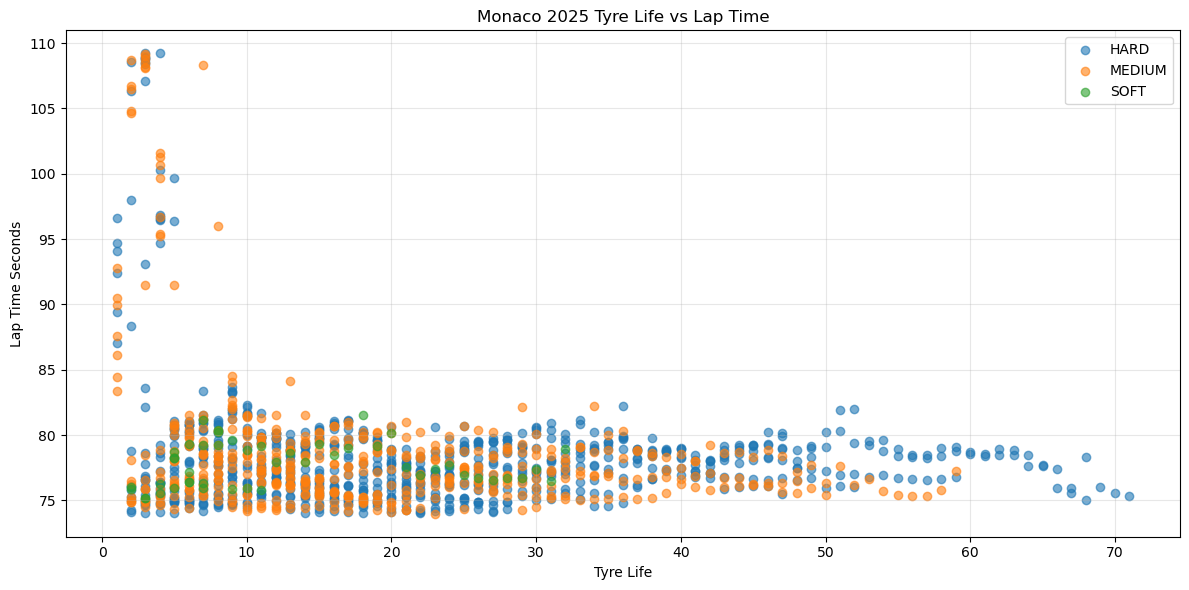

In [17]:
plt.figure(figsize=(12, 6))

for compound in racing_laps_filtered["Compound"].dropna().unique():
    compound_data = racing_laps_filtered[racing_laps_filtered["Compound"] == compound]
    plt.scatter(
        compound_data["TyreLife"],
        compound_data["LapTimeSeconds"],
        alpha=0.6,
        label=compound
    )

plt.title("Monaco 2025 Tyre Life vs Lap Time")
plt.xlabel("Tyre Life")
plt.ylabel("Lap Time Seconds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUTS_DIR / "monaco_2025_tyre_life_vs_lap_time.png", dpi=300)
plt.show()

## Stint Summary

A stint is a continuous run on one set of tyres. This summary helps us understand each driver's strategy, including which compounds they used and how many laps they completed on each set.

In [18]:
stint_summary = (
    clean_laps
    .groupby(["Driver", "Stint", "Compound"])
    .agg(
        StartLap=("LapNumber", "min"),
        EndLap=("LapNumber", "max"),
        LapsInStint=("LapNumber", "count"),
        AvgLapTimeSeconds=("LapTimeSeconds", "mean"),
        MedianLapTimeSeconds=("LapTimeSeconds", "median"),
        MinLapTimeSeconds=("LapTimeSeconds", "min"),
        MaxTyreLife=("TyreLife", "max")
    )
    .reset_index()
    .sort_values(["Driver", "Stint"])
)

stint_summary.head(30)

,Driver,Stint,Compound,StartLap,EndLap,LapsInStint,AvgLapTimeSeconds,MedianLapTimeSeconds,MinLapTimeSeconds,MaxTyreLife
0,ALB,1.0,MEDIUM,1.0,32.0,32,82.339531,79.7385,76.556,36.0
1,ALB,2.0,MEDIUM,33.0,40.0,8,79.271875,76.2830,75.303,16.0
2,ALB,3.0,HARD,41.0,76.0,36,77.129778,76.2990,74.597,36.0
3,ALO,1.0,HARD,1.0,16.0,16,85.286625,80.3230,75.593,17.0
4,ALO,2.0,HARD,17.0,36.0,20,77.125800,77.0330,75.823,21.0
5,ANT,1.0,HARD,1.0,69.0,69,80.727899,79.0930,75.019,69.0
6,ANT,2.0,MEDIUM,70.0,71.0,2,85.507500,85.5075,79.503,2.0
7,ANT,3.0,HARD,72.0,75.0,4,75.253000,74.2425,73.518,4.0
8,BEA,1.0,MEDIUM,1.0,1.0,1,139.932000,139.9320,139.932,1.0
9,BEA,2.0,HARD,2.0,17.0,16,83.631938,79.4780,74.855,16.0


In [19]:
stint_summary_path = PROCESSED_DATA_DIR / "2025_monaco_stint_summary.csv"
stint_summary.to_csv(stint_summary_path, index=False)

print("Saved stint summary:")
print(stint_summary_path)

Saved stint summary:
../data/processed/2025_monaco_stint_summary.csv


## Driver Consistency

Standard deviation of lap time gives a simple measure of consistency. A lower value means the driver's clean lap times were more stable.

In [20]:
driver_consistency = (
    racing_laps_filtered
    .groupby("Driver")["LapTimeSeconds"]
    .agg(["mean", "std", "count"])
    .sort_values("std")
)

driver_consistency

,mean,std,count
Driver,,,
BEA,78.187662,1.625634,71
BOR,78.077638,1.673325,69
STR,79.036714,3.569417,70
TSU,79.374264,4.152569,72
HAD,78.377347,4.577914,72
HUL,79.482620,4.663080,71
OCO,78.348764,4.664570,72
ANT,79.993088,4.761546,68
LAW,78.363875,4.832104,72


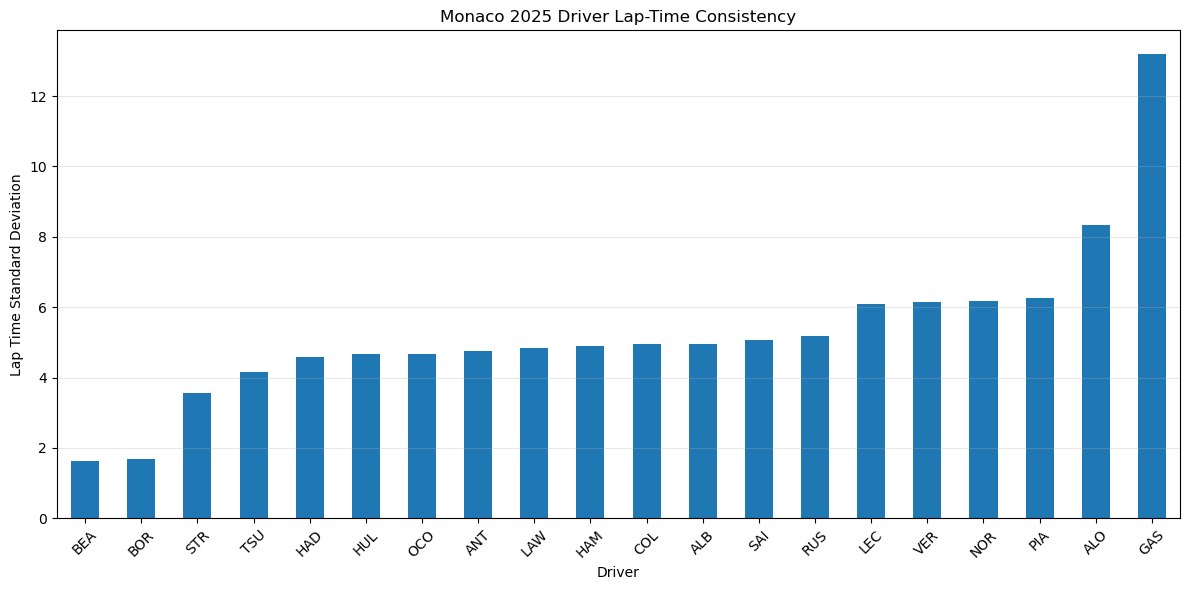

In [21]:
plt.figure(figsize=(12, 6))

driver_consistency["std"].plot(kind="bar")

plt.title("Monaco 2025 Driver Lap-Time Consistency")
plt.xlabel("Driver")
plt.ylabel("Lap Time Standard Deviation")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUTS_DIR / "monaco_2025_driver_consistency.png", dpi=300)
plt.show()

## Save Cleaned Data

The cleaned dataset keeps valid lap-time rows and includes useful flags such as `IsPitLap` and `LapTimeSeconds`.

This file will be used in the next notebook for tyre degradation analysis.

In [22]:
clean_laps_path = PROCESSED_DATA_DIR / "2025_monaco_clean_laps.csv"
racing_laps_filtered_path = PROCESSED_DATA_DIR / "2025_monaco_racing_laps_filtered.csv"

clean_laps.to_csv(clean_laps_path, index=False)
racing_laps_filtered.to_csv(racing_laps_filtered_path, index=False)

print("Saved cleaned files:")
print(clean_laps_path)
print(racing_laps_filtered_path)

Saved cleaned files:
../data/processed/2025_monaco_clean_laps.csv
../data/processed/2025_monaco_racing_laps_filtered.csv


In [24]:
# Create a stricter dataset for tyre degradation analysis

tyre_analysis_laps = clean_laps.copy()

# Remove pit laps
tyre_analysis_laps = tyre_analysis_laps[tyre_analysis_laps["IsPitLap"] == False].copy()

# Remove rows with missing key tyre analysis fields
tyre_analysis_laps = tyre_analysis_laps.dropna(
    subset=["LapTimeSeconds", "TyreLife", "Compound", "Stint", "Driver"]
)

# Remove early race laps where lap times may be affected by start/restart effects
tyre_analysis_laps = tyre_analysis_laps[tyre_analysis_laps["LapNumber"] > 5].copy()

# Keep normal Monaco racing pace range
tyre_analysis_laps = tyre_analysis_laps[
    (tyre_analysis_laps["LapTimeSeconds"] >= 73) &
    (tyre_analysis_laps["LapTimeSeconds"] <= 83)
].copy()

print("Clean laps:", clean_laps.shape)
print("Racing laps:", racing_laps.shape)
print("Filtered racing laps:", racing_laps_filtered.shape)
print("Tyre analysis laps:", tyre_analysis_laps.shape)

tyre_analysis_laps[
    ["Driver", "LapNumber", "LapTimeSeconds", "Compound", "TyreLife", "Stint", "TrackStatus"]
].head()

Clean laps: (1423, 33)
Racing laps: (1343, 33)
Filtered racing laps: (1315, 33)
Tyre analysis laps: (1243, 33)


,Driver,LapNumber,LapTimeSeconds,Compound,TyreLife,Stint,TrackStatus
5,VER,6.0,80.011,HARD,6.0,1.0,1
6,VER,7.0,78.968,HARD,7.0,1.0,1
7,VER,8.0,77.714,HARD,8.0,1.0,12
8,VER,9.0,81.205,HARD,9.0,1.0,2
9,VER,10.0,79.169,HARD,10.0,1.0,2


In [25]:
tyre_analysis_laps_path = PROCESSED_DATA_DIR / "2025_monaco_tyre_analysis_laps.csv"

tyre_analysis_laps.to_csv(tyre_analysis_laps_path, index=False)

print("Saved tyre analysis dataset:")
print(tyre_analysis_laps_path)

Saved tyre analysis dataset:
../data/processed/2025_monaco_tyre_analysis_laps.csv


In [26]:
tyre_analysis_laps["LapTimeSeconds"].describe()

count    1243.000000
mean       77.386281
std         1.956398
min        73.221000
25%        75.800000
50%        77.233000
75%        78.901000
max        82.712000
Name: LapTimeSeconds, dtype: float64

In [27]:
tyre_analysis_laps["Compound"].value_counts()

Compound
HARD      759
MEDIUM    436
SOFT       48
Name: count, dtype: int64

In [28]:
tyre_analysis_laps["TrackStatus"].value_counts()

TrackStatus
1     1157
12      36
2       31
21      19
Name: count, dtype: int64

## Phase 2 Summary

In this notebook, we cleaned the raw Monaco 2025 race lap data and created numeric lap-time values in seconds.

We also identified pit laps, inspected tyre compounds and stints, removed extreme outliers for exploratory analysis, and created visualizations for race pace, average driver pace, tyre compound comparison, tyre life, and driver consistency.

In addition, we created a stricter tyre analysis dataset that removes pit laps, early-race laps, and abnormal slow laps. This dataset will be used in Phase 3 so that tyre degradation trends are not distorted by non-racing-pace laps.

The cleaned files from this phase will be used in Phase 3 for tyre degradation analysis.